<a href="https://colab.research.google.com/github/a2r4vind/Data_Science_Learning_and_Practice/blob/main/Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [6]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

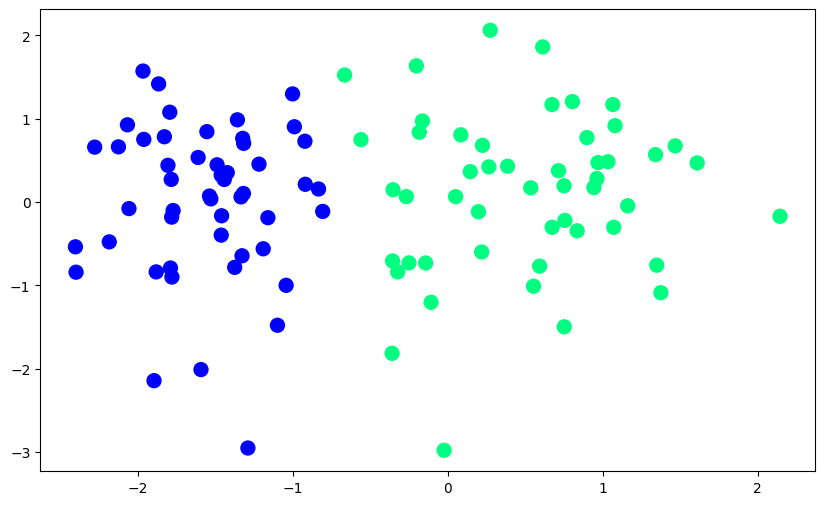

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [8]:
def perceptron(X,y):
  # add bias(W0) column
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100) # because of 100 samples
    y_cap = step(np.dot(X[j], weights))
    weights = weights + lr * (y[j] - y_cap) * X[j]

  return weights[0], weights[1:]

In [9]:
# Defining step function
def step(Z):
  return 1 if Z > 0 else 0

In [10]:
intercept_, coef_ = perceptron(X, y)

In [11]:
print(coef_)
print(intercept_)

[1.28919966 0.15675147]
1.0


In [12]:
# getting the slope and y_intercept of the straight desicion boundary(line)
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [13]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

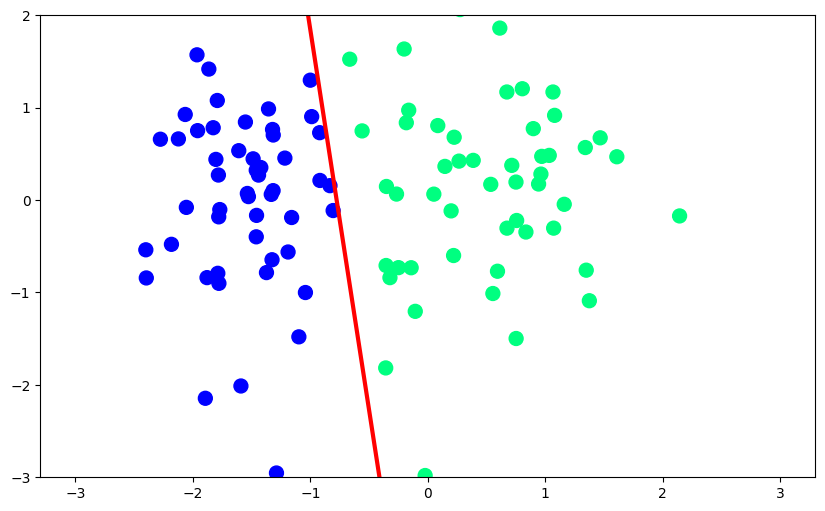

In [16]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)
